In [35]:
import env
import numpy as np

In [36]:
# Create the environment
environment = env.env()

In [37]:
# Reset the environment
environment.reset()

In [38]:
# Observe the first agent
observation = environment.observe('player_0')
print(observation)

{'observation': array([[1., 1., 2., 0., 1.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [5., 5., 5., 5., 5.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]]), 'action_mask': (array([1, 0, 0, 0], dtype=int8), array([1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8))}


{'player_0': 5127, 'player_1': 4873}
10000
10000


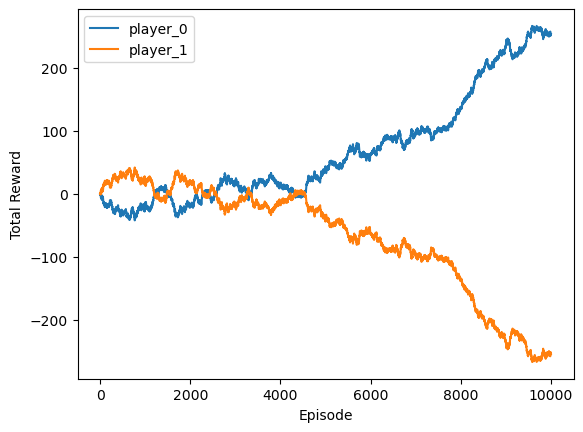

In [39]:
import random

# Initialize variables for training
num_episodes = 10000
reward_history = {
    'player_0': [],
    'player_1': []
}

wins = {
    'player_0': 0,
    'player_1': 0
}
for episode in range(num_episodes):
    environment.reset()
    episode_reward = 0



    for agent in environment.agent_iter():
        observation, reward, termination, truncation, info = environment.last()

        if termination or truncation:
            action = None
            # print(reward)
            reward_history[agent].append((reward + reward_history[agent][-1]) if len(reward_history[agent]) > 0 else reward)
            wins[agent] += 1 if reward > 0 else 0
            # print(environment.rewards)
        else:
            mask = observation["action_mask"]
            # this is where you would insert your policy
            action = environment.action_space(agent).sample(mask)

        environment.step(action)

    
    # print(f"Episode {episode + 1}: Total Reward: {episode_reward}")

environment.close()
print(wins)

print(len(reward_history['player_0']))
print(len(reward_history['player_1']))

# print(reward_history)

# Plot the reward history
import matplotlib.pyplot as plt

plt.plot(reward_history['player_0'], label='player_0')
plt.plot(reward_history['player_1'], label='player_1')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.show()



In [40]:
print(reward_history['player_0'])

[-1, -2, -1, -2, -1, 0, -1, 0, 1, 0, -1, -2, -1, 0, -1, -2, -3, -4, -5, -6, -5, -4, -5, -6, -7, -6, -7, -8, -7, -8, -7, -6, -5, -6, -5, -4, -3, -2, -3, -4, -5, -6, -7, -8, -7, -8, -9, -10, -9, -8, -7, -6, -7, -6, -5, -6, -7, -6, -5, -4, -5, -6, -7, -6, -5, -6, -7, -6, -7, -8, -9, -10, -11, -12, -13, -14, -15, -14, -15, -16, -15, -14, -15, -14, -15, -14, -15, -14, -13, -14, -13, -14, -15, -16, -17, -18, -17, -16, -17, -16, -17, -18, -19, -20, -19, -20, -21, -20, -21, -20, -19, -18, -19, -20, -19, -18, -17, -18, -17, -18, -17, -16, -15, -16, -15, -16, -17, -16, -17, -16, -17, -16, -15, -16, -17, -18, -19, -18, -17, -16, -17, -16, -17, -18, -19, -20, -21, -22, -21, -20, -21, -20, -21, -22, -21, -20, -19, -18, -17, -16, -17, -18, -19, -20, -19, -20, -21, -20, -19, -20, -21, -20, -19, -20, -21, -20, -19, -20, -19, -18, -19, -20, -19, -18, -19, -20, -19, -18, -17, -16, -17, -16, -17, -18, -19, -20, -21, -20, -19, -18, -17, -16, -17, -16, -15, -16, -17, -16, -17, -16, -15, -16, -15, -16, -15,